In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm
from scipy.interpolate import griddata

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.stats import gaussian_kde
from scipy.ndimage.filters import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_65046/4184058898.py:31: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [3]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [6]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [7]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [8]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [9]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [10]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [11]:
mpeak_hist=[[],]
gal_num_exl=[]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        gal_num_exl.append(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

In [12]:
mask_exl=(tab2['aper_100_gal']>0)
for i in gal_num_exl:
    mask_exl=mask_exl&(tab2['gal_num']!=i)

In [13]:
def halo_mass_growth(gal_num_list,snap0,snap1):
    grow_tab=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if len(mpeak_hist[gal_num][0])>1:
                x=age_tab[mpeak_hist[gal_num][0]]
                y=np.asarray(mpeak_hist[gal_num][1])
                mask00=(x>1)
                if np.min(x[mask00])<age_tab[snap0-2]:
                    f=interp1d(x[mask00],y[mask00],kind='linear')
                    age0=age_tab[snap0]
                    age1=age_tab[snap1]
                    y0=f(age0)
                    y1=f(age1)
                    growth=y1-y0
                    grow_tab.append(growth)
                else:
                    grow_tab.append(None)
            else:
                grow_tab.append(None)
    return np.asarray(grow_tab)

In [14]:
tab2['halo_growth_z1_z2']= halo_mass_growth(np.arange(3388),33,50)
tab2['halo_growth_z0.4_z1']=halo_mass_growth(np.arange(3388),50,72)
tab2['halo_growth_z0.7_z1.5']=halo_mass_growth(np.arange(3388),40,59)

In [15]:
def random_noise_on_richness(data,error=2,times=30):
    n=len(data)
    data0=np.asarray([[data]])
    for i in range(times):
        data0=np.append(data0,[[data+np.random.normal(loc=0,scale=error,size=n)]],axis=1)
    data1=data0[0].T
    data_mean=np.sum(data1,axis=1)/times
    return data_mean

In [16]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_50081/3090260260.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


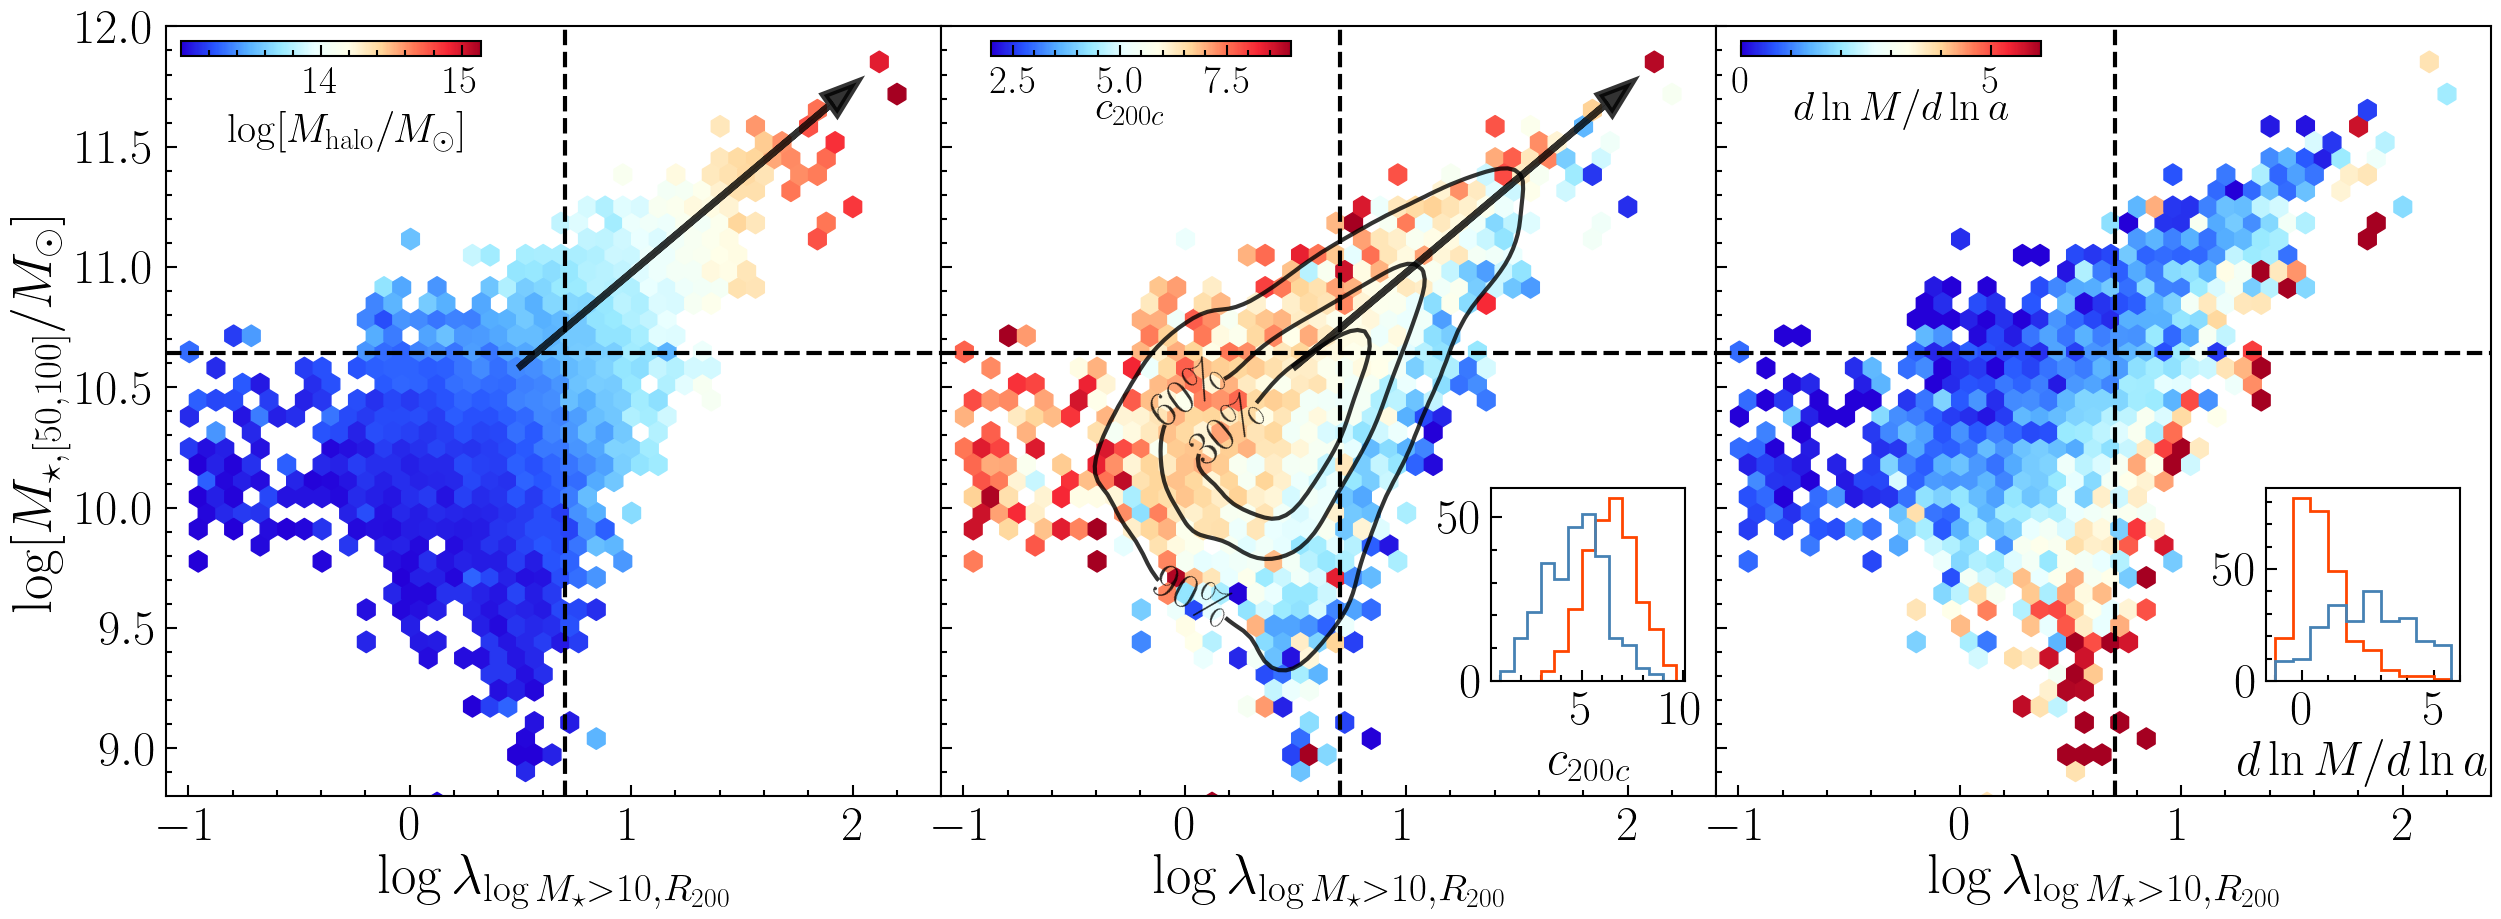

In [16]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax3,ax1,ax2)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.1,0.88,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$d\ln M/d\ln a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')


plt.savefig(fig_dir+"Fig3.pdf",dpi=150)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_31671/3718666130.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


(-1.1, 2.4)

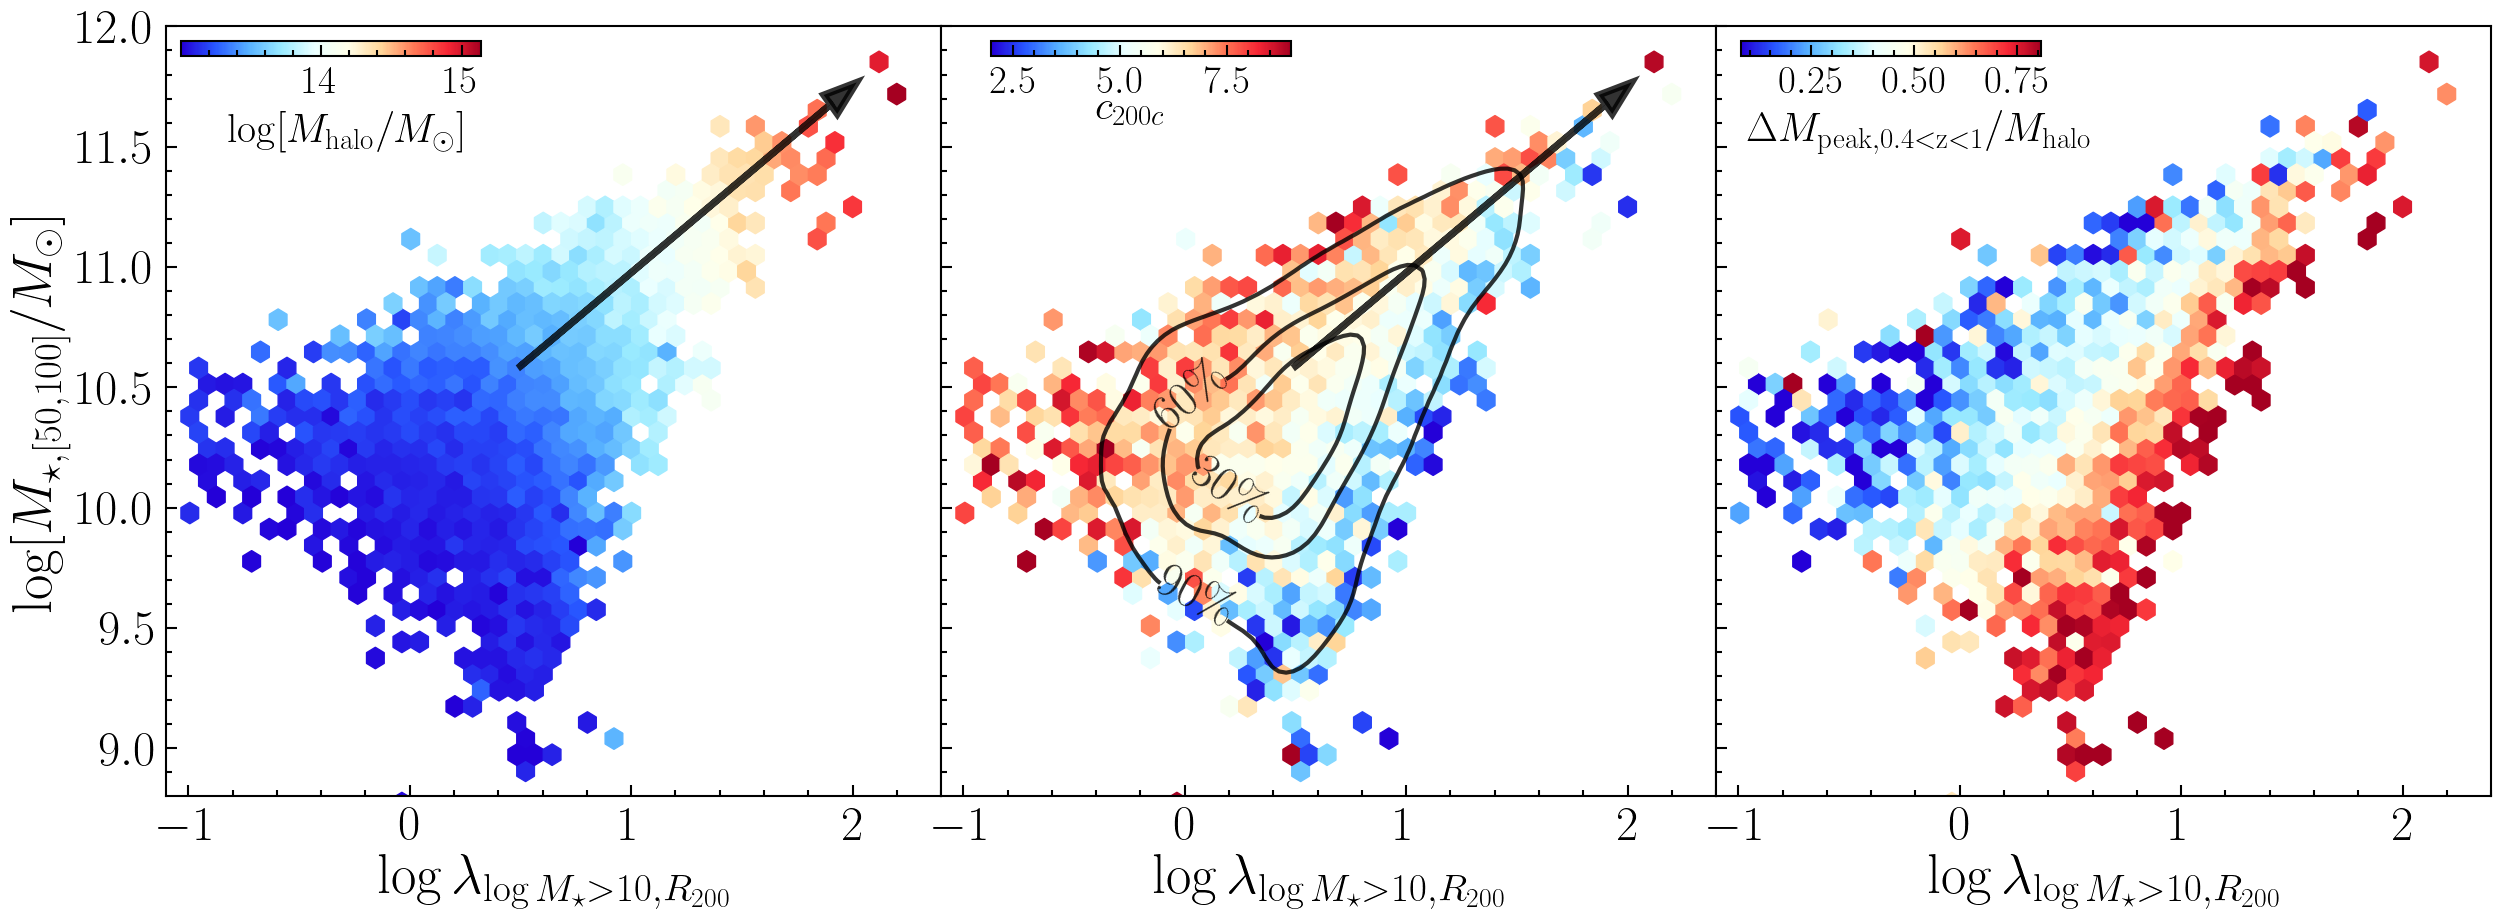

In [22]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax3,ax1,ax2)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax2.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax2.text(0.04,0.85,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax2.transAxes,size=30)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)



/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_31671/2991623748.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


Text(0.05, 0.05, '\\rm Halo Growth at $0.4<z<1$')

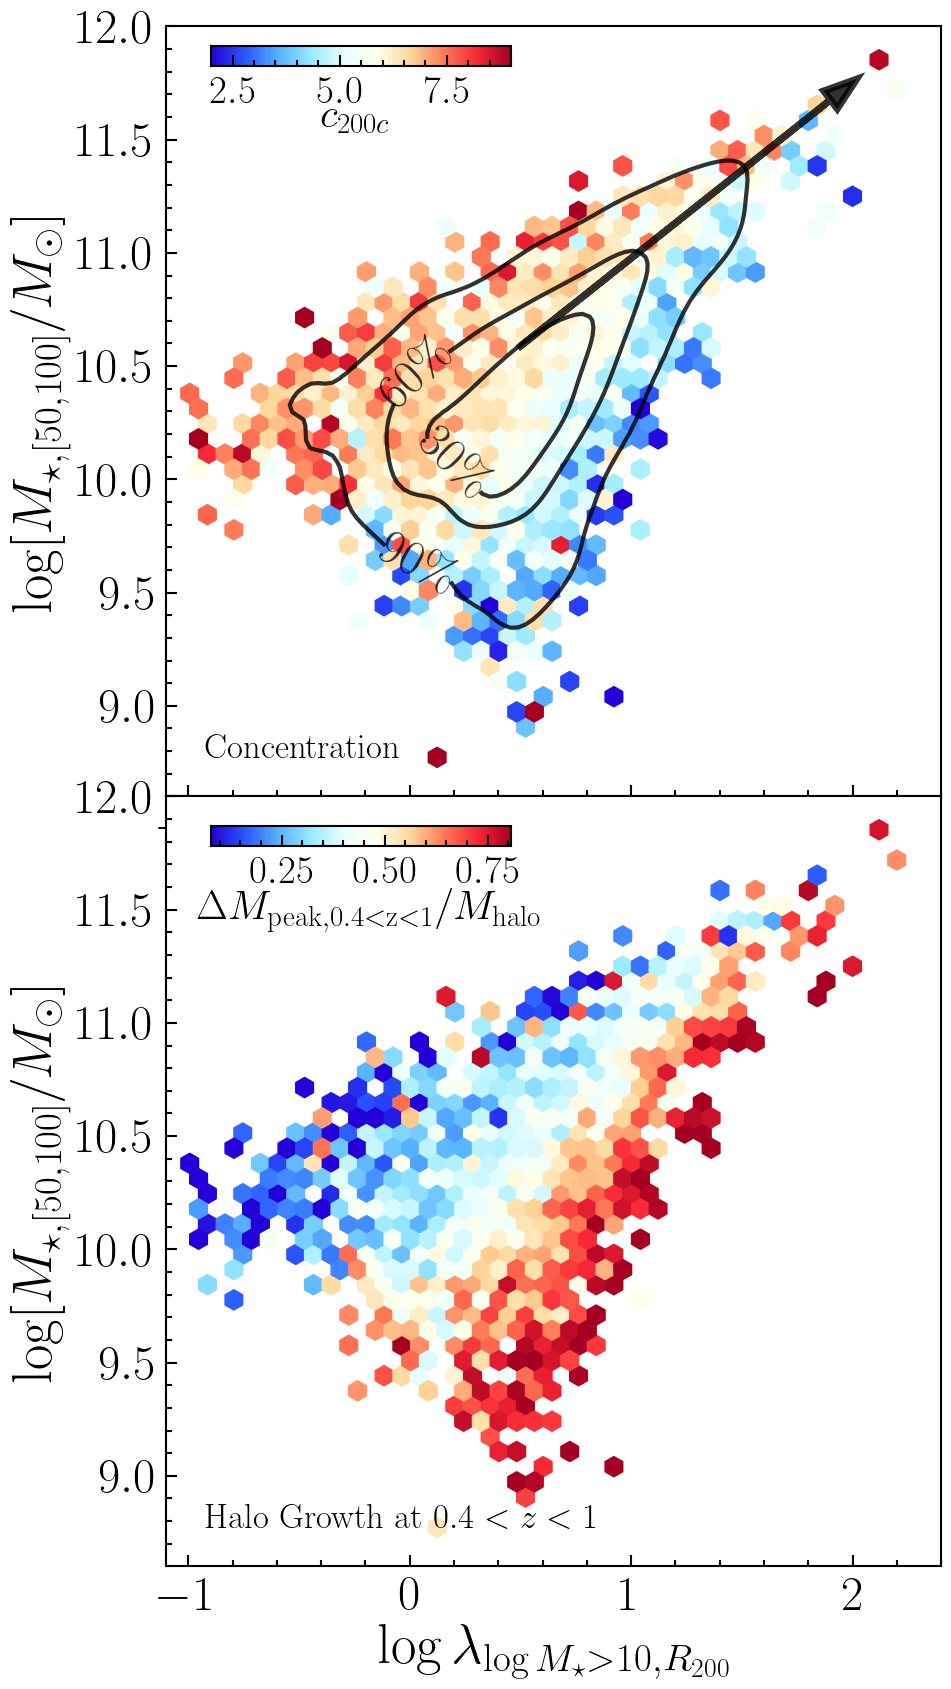

In [36]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(10,20))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0)
(ax1,ax2)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.17, 0.86, 0.3, 0.01])
ax1.text(0.2,0.87,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax2.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax2.text(0.04,0.84,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax2.transAxes,size=30)
cax = fig.add_axes([0.17, 0.47, 0.3, 0.01])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax2.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.6,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.6,12)
ax2.set_xlim(-1.1,2.4)

ax1.text(0.05,0.05,r'\rm Concentration',transform=ax1.transAxes,size=25)
ax2.text(0.05,0.05,r'\rm Halo Growth at $0.4<z<1$',transform=ax2.transAxes,size=25)



/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_65046/3998709171.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


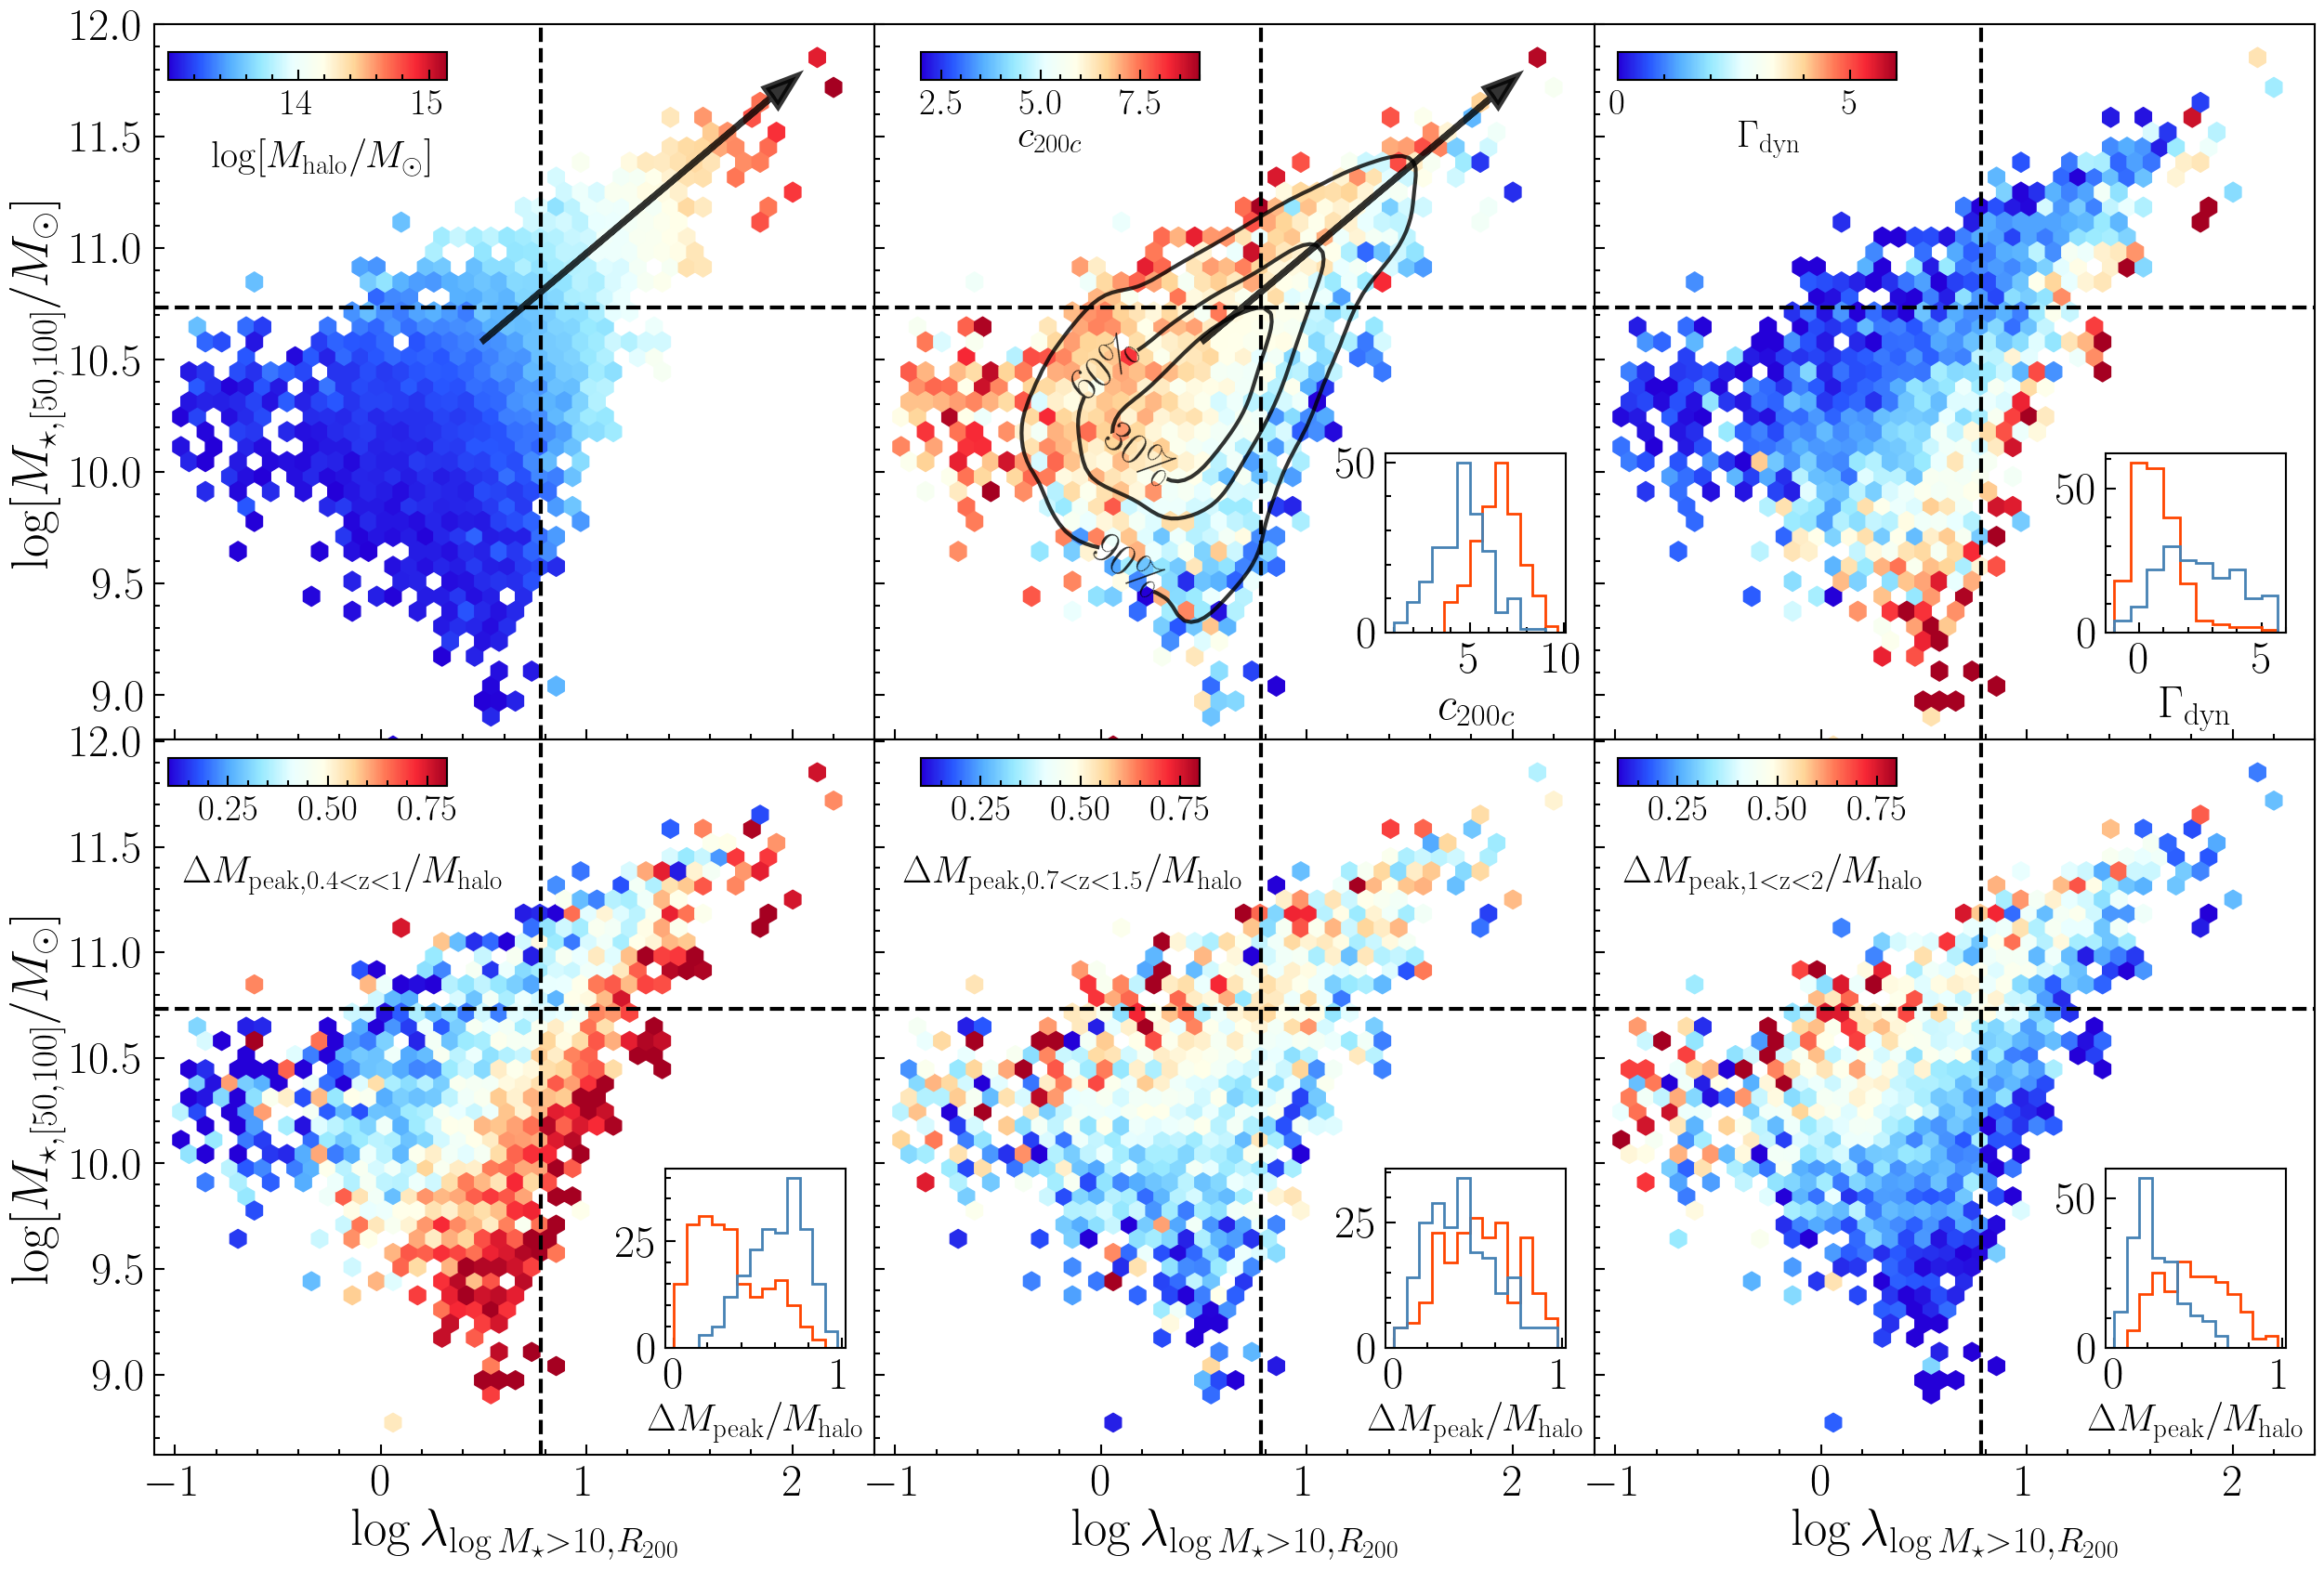

In [18]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=600
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,20))
gs = fig.add_gridspec(2,3, hspace=0, wspace=0)
(ax3,ax1,ax2),(ax4,ax5,ax6)=gs.subplots(sharey='row',sharex='col')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.83,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.2,0.83,r'$\Gamma_{\rm dyn}$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.8,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=0.1
vmax=0.8
SC=ax4.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax4.text(0.04,0.8,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax4.transAxes,size=30)
cax = fig.add_axes([0.13, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax4.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax4.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

name_z='halo_growth_z0.7_z1.5'
mask_z=(tab2['halo_growth_z0.7_z1.5'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.7_z1.5']/tab2[mask10][mask_z]['mass_halo']
vmin=0.1
vmax=0.8
SC=ax5.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax5.text(0.04,0.8,r'$\Delta M_{\rm peak,0.7<z<1.5}/M_{\rm halo}$',transform=ax5.transAxes,size=30)
cax = fig.add_axes([0.4, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax5.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax5.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

mask_z=(tab2['halo_growth_z1_z2'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z1_z2']/tab2[mask10][mask_z]['mass_halo']
vmin=0.1
vmax=0.8
SC=ax6.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax6.text(0.04,0.8,r'$\Delta M_{\rm peak,1<z<2}/M_{\rm halo}$',transform=ax6.transAxes,size=30)
cax = fig.add_axes([0.65, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax6.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax6.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data['halo_growth_z1_z2']!=None)
mask_11=(down_data['halo_growth_z1_z2']!=None)
ax10.hist(up_data[mask_00]['halo_growth_z1_z2']/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11]['halo_growth_z1_z2']/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

ax4.set_xlabel(label,fontsize=40)
ax5.set_xlabel(label,fontsize=40)
ax6.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Gamma_{\rm dyn}$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax4.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')
ax4.axvline(x_v,c='black',lw=3,ls='--')
ax4.axhline(y_v,c='black',lw=3,ls='--')
ax5.axvline(x_v,c='black',lw=3,ls='--')
ax5.axhline(y_v,c='black',lw=3,ls='--')
ax6.axvline(x_v,c='black',lw=3,ls='--')
ax6.axhline(y_v,c='black',lw=3,ls='--')

plt.savefig(fig_dir+"Fig3.pdf",dpi=150)

(-1.1, 2.4)

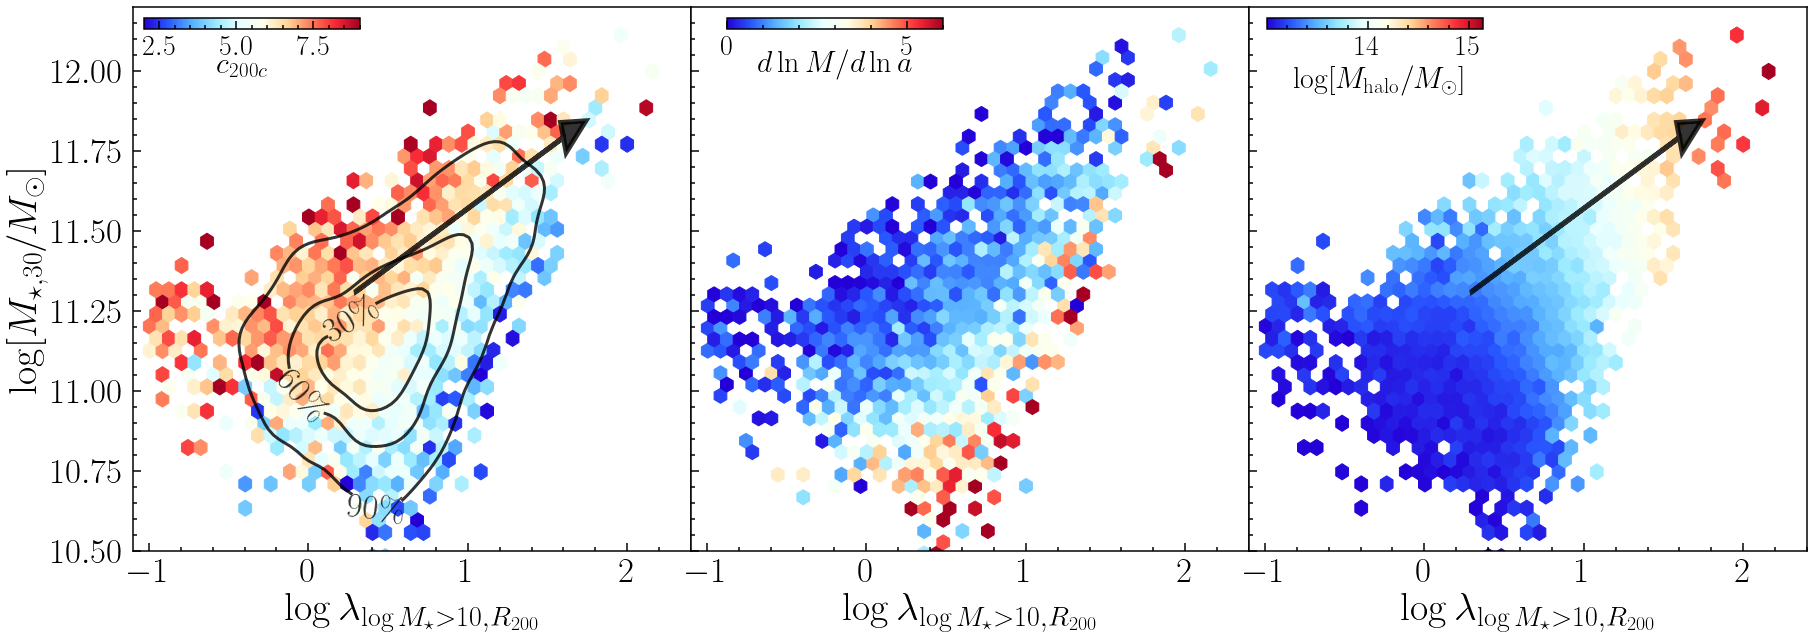

In [29]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>14)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_30_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax1,ax2,ax3)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask1=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask1])
ydata=np.log10(tab2[mask1]['aper_30_gal'])
zdata=tab2[mask1]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
ax1.text(0.15,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask1]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.12,0.88,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask1]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)



xline=np.arange(0.3,1.7,0.1)
yline=11.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(-0.1,9.5),(0,11),(0.3,11.2)])
ax1.set_ylim(10.5,12.2)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(10.5,12.2)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(10.5,12.2)
ax3.set_xlim(-1.1,2.4)

<a list of 3 text.Text objects>

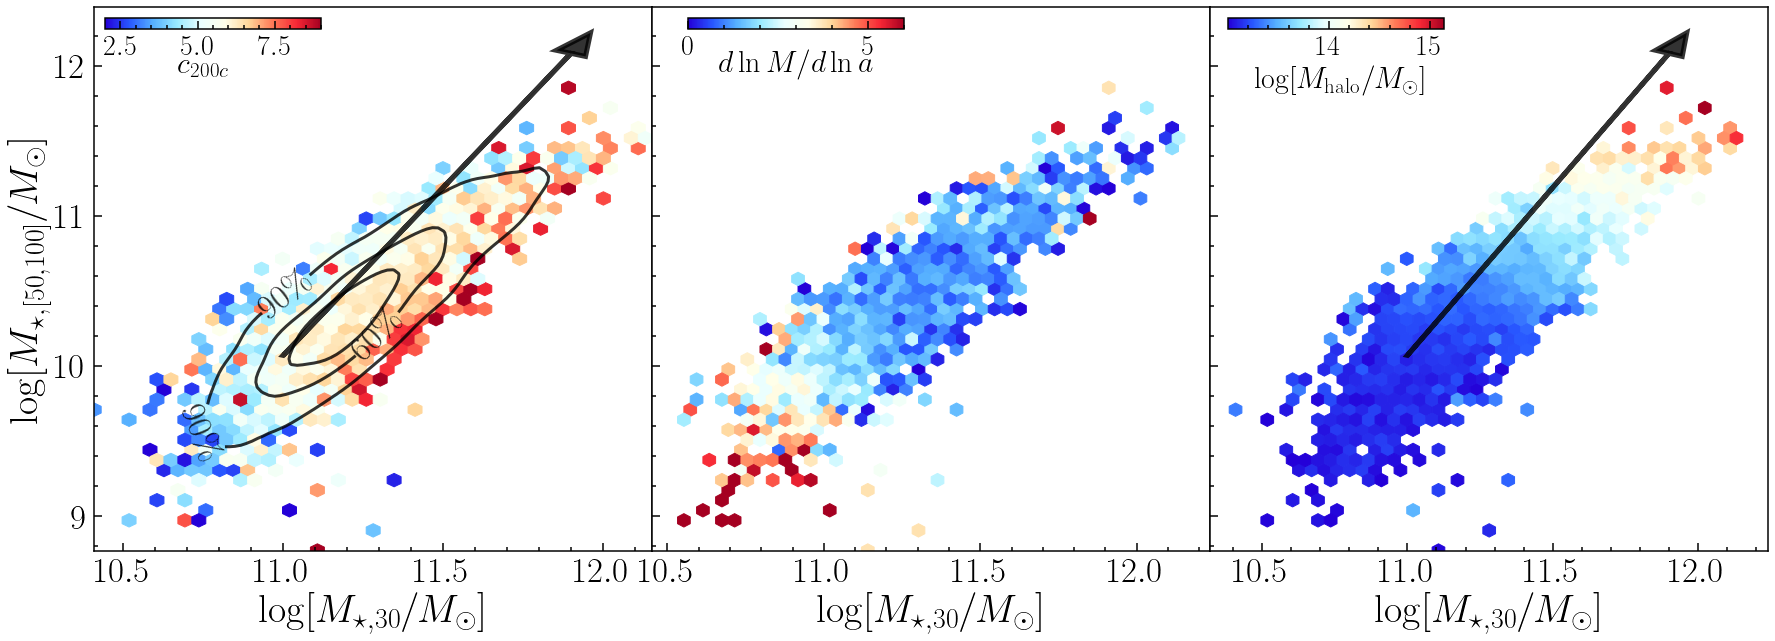

In [47]:
name='aper_30_gal'
mask2=(np.log10(tab2['mass_halo'])>13.7)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax1,ax2,ax3)=gs.subplots(sharey='row')
name='aper_30_gal'
label=r'$\log[M_{\star,30}/M_\odot]$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask1=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask1])
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
zdata=tab2[mask1]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
ax1.text(0.15,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask1]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.12,0.88,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask1]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)



xline=np.arange(11,12,0.1)
yline=-14.5+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(10.5,9.5),(11,10.5),(11.3,10.2)])
# ax1.set_ylim(8.8,12)
# ax1.set_xlim(-1.1,2.4)
# ax2.set_ylim(8.8,12)
# ax2.set_xlim(-1.1,2.4)
# ax3.set_ylim(8.8,12)
# ax3.set_xlim(-1.1,2.4)

(-1.1, 2.4)

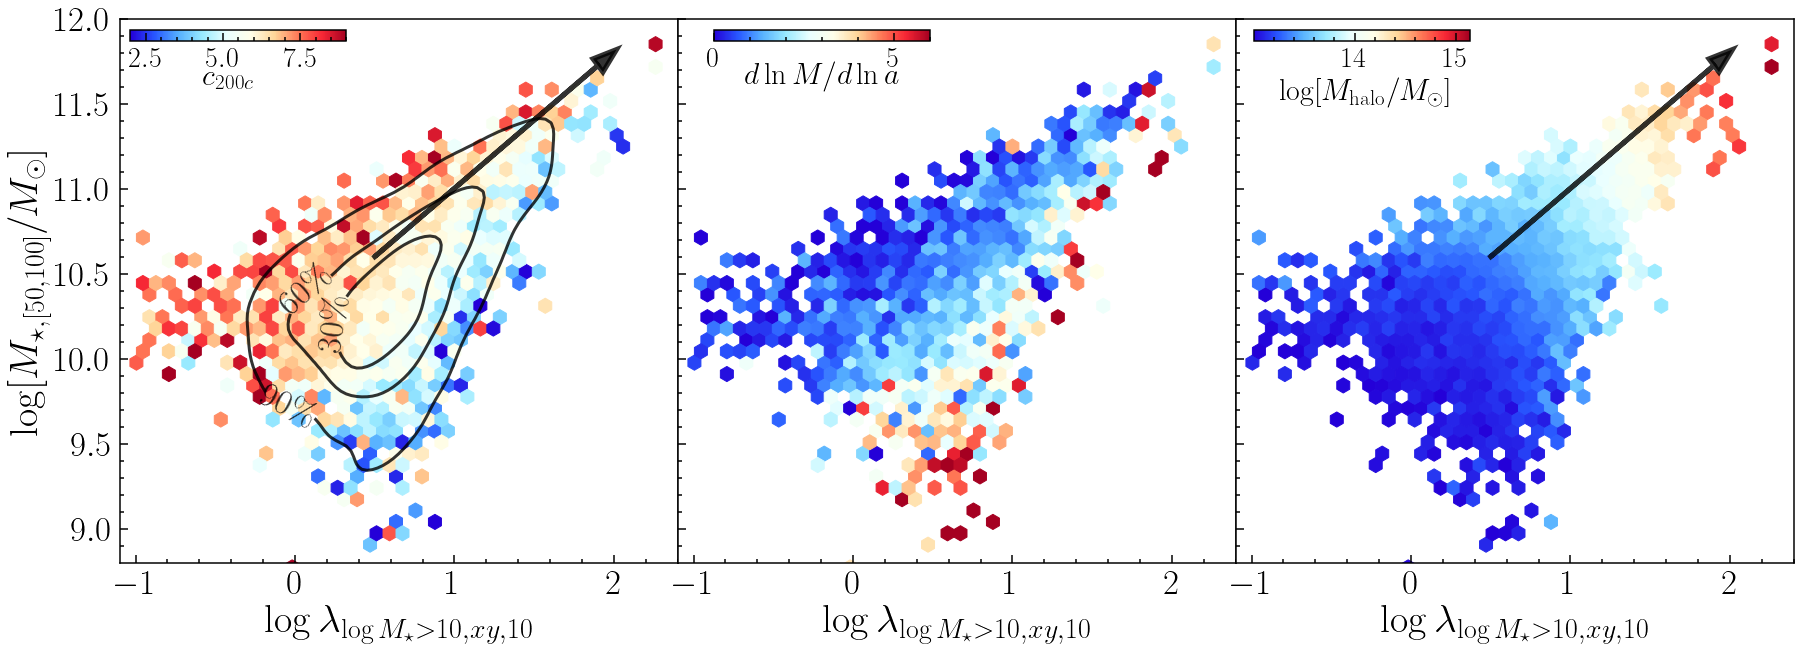

In [48]:
name='richness_cut_r200_10_xy_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax1,ax2,ax3)=gs.subplots(sharey='row')
name='richness_cut_r200_10_xy_10'
label=r'$\log\lambda_{\log M_\star>10,xy,10}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask1=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask1])
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
zdata=tab2[mask1]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
ax1.text(0.15,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask1]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.12,0.88,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask1]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)



xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(-0.1,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_63678/2767894145.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


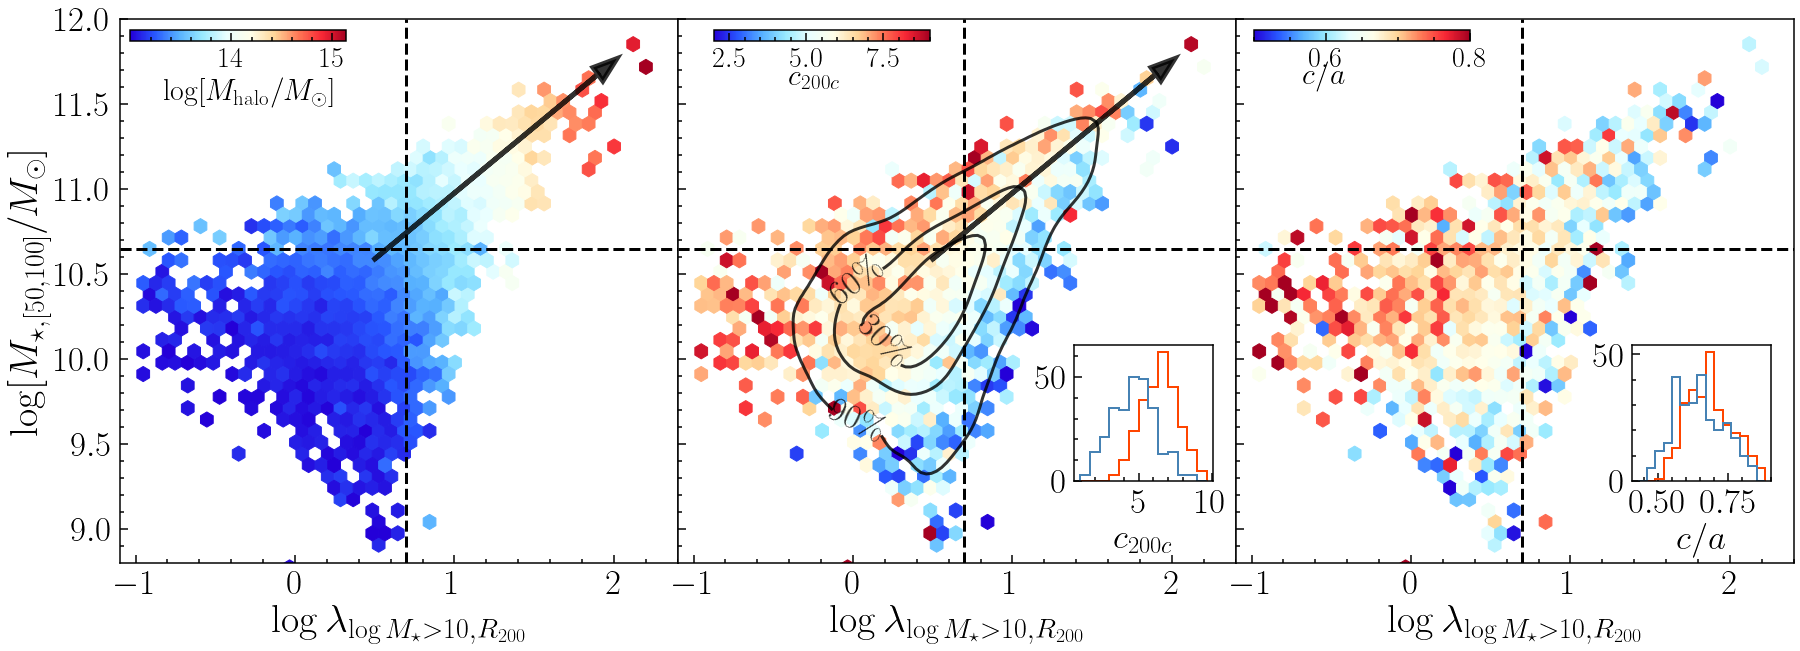

In [19]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
(ax3,ax1,ax2)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.88,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['c_to_a_3d']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0.5,vmax=0.8)
ax2.text(0.12,0.88,r'$c/a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.85,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(0.43,0.9,0.03)
ax10.hist(up_data['c_to_a_3d'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_to_a_3d'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c/a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_21339/2405843856.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


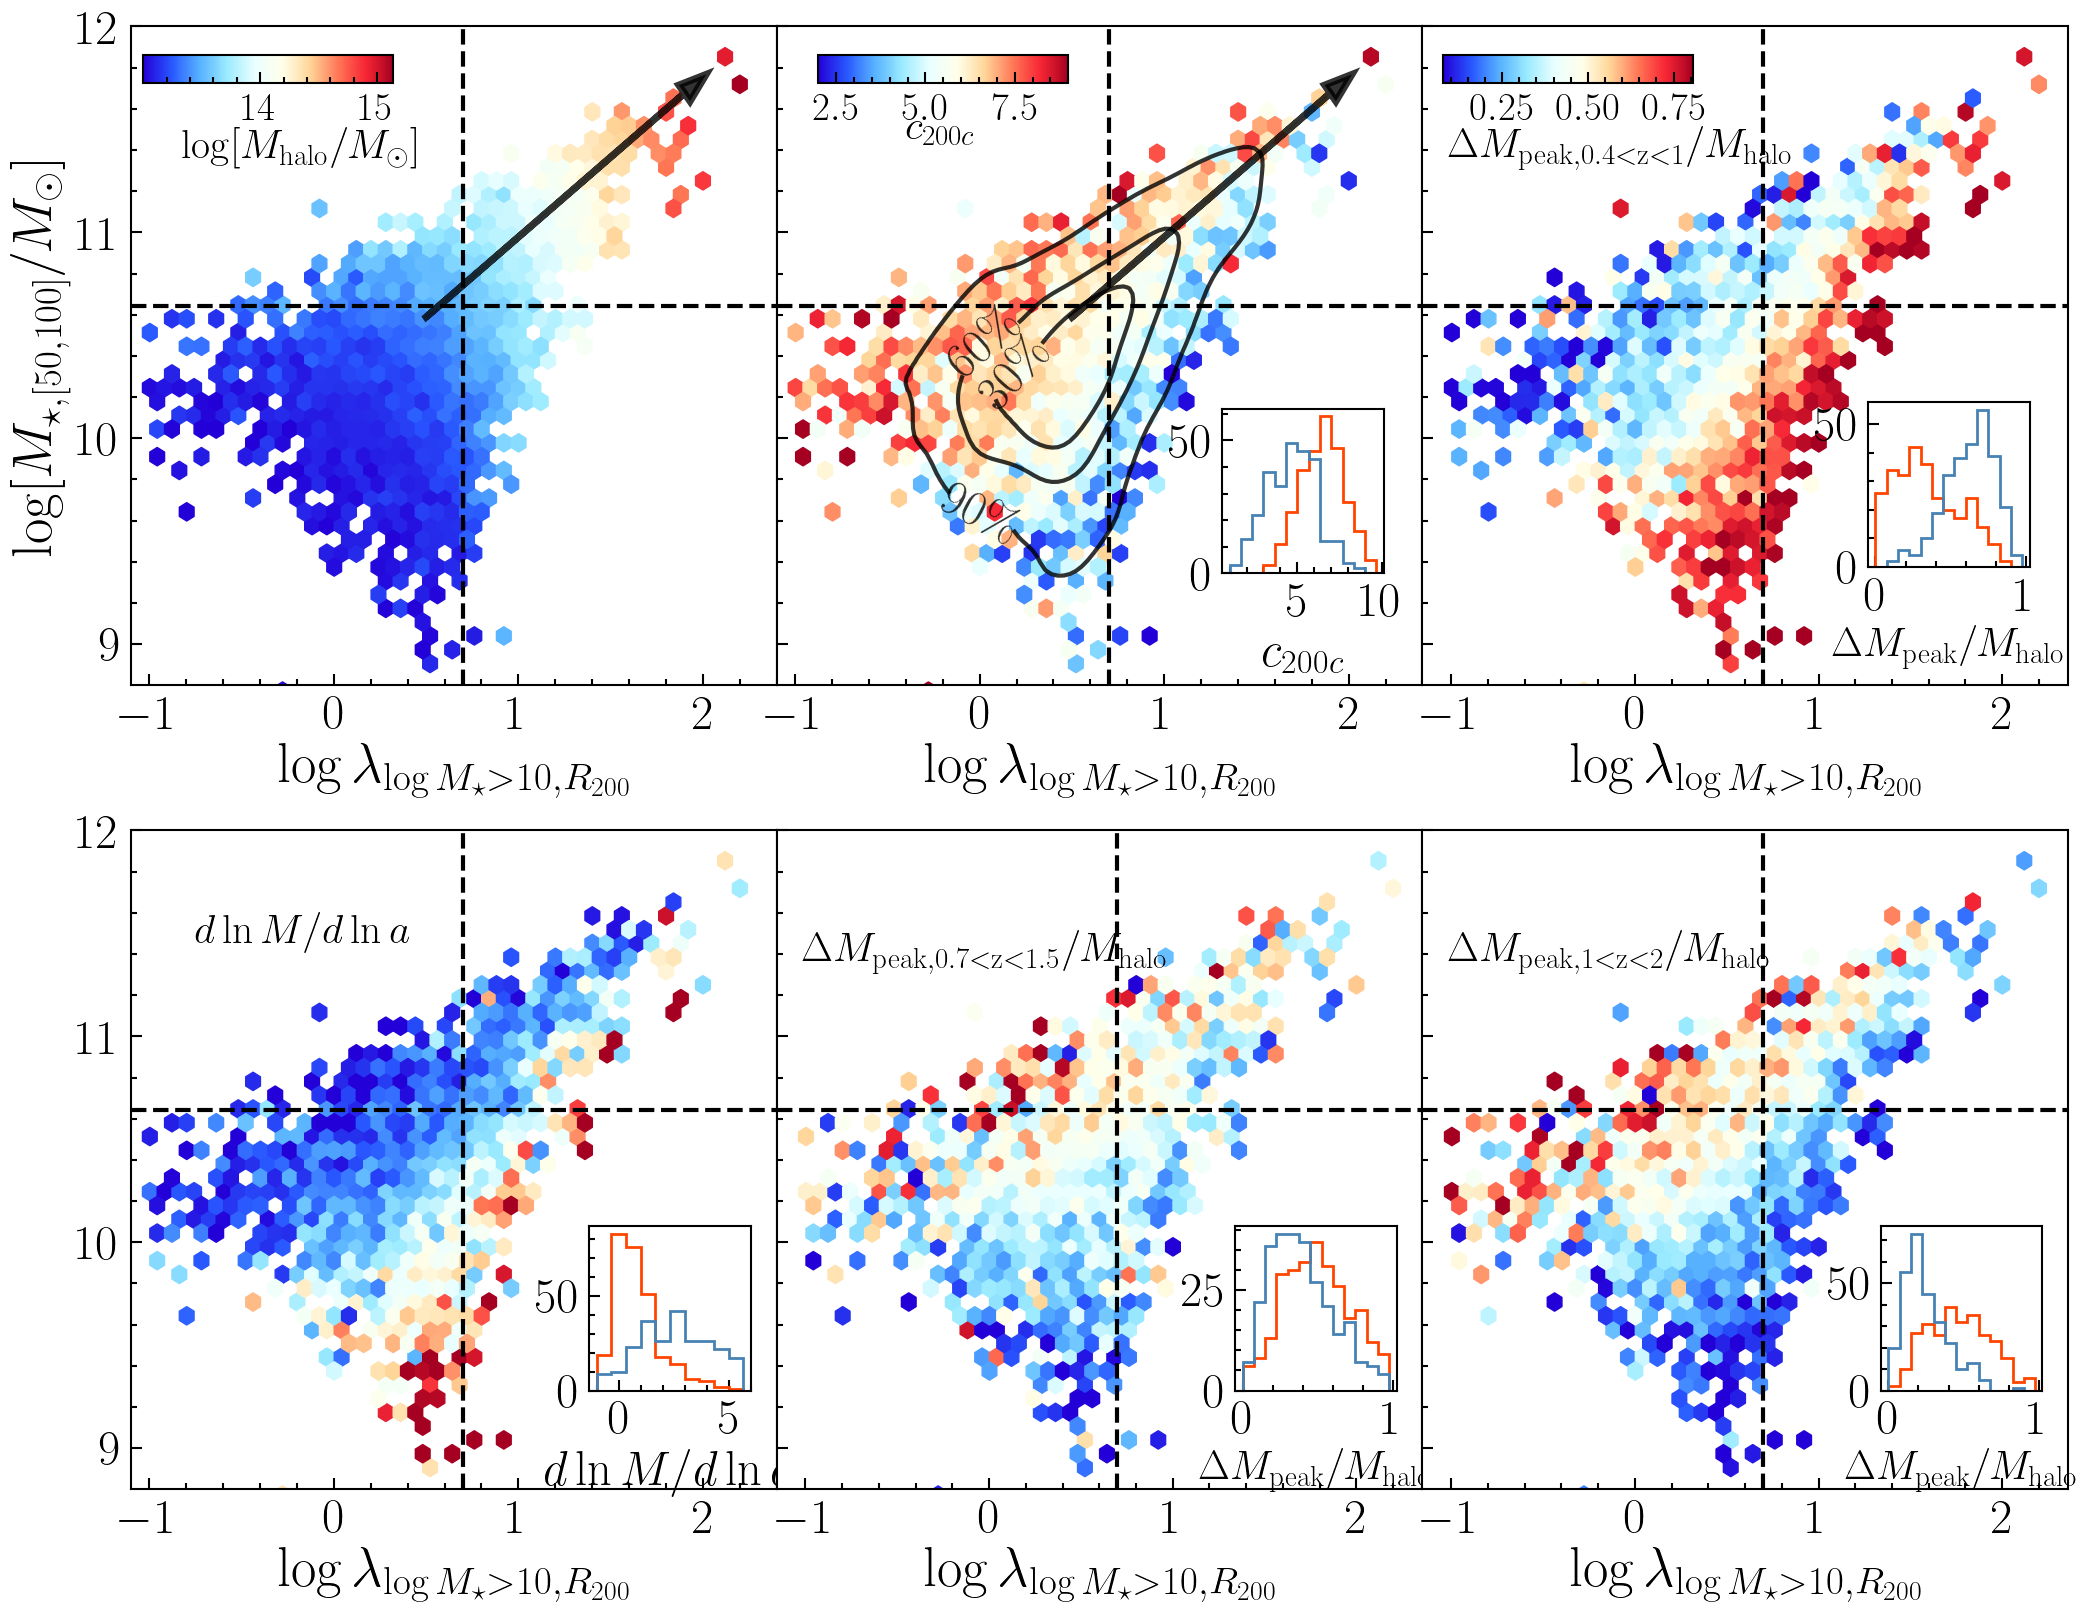

In [32]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(25,19), facecolor='none')
gs = fig.add_gridspec(2,3, hspace=0.22, wspace=0)
(ax3,ax1,ax4),(ax2,ax5,ax6)=gs.subplots(sharey='row')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.83,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.1,0.83,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.69, 0.17, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
# cax = fig.add_axes([0.13, 0.47, 0.1, 0.015])
# cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.8,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax4.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax4.text(0.04,0.8,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax4.transAxes,size=30)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


ax10 = ax4.inset_axes([0.69, 0.18, 0.25,0.25], transform=ax4.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

name_z='halo_growth_z0.7_z1.5'
mask_z=(tab2['halo_growth_z0.7_z1.5'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.7_z1.5']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax5.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax5.text(0.04,0.8,r'$\Delta M_{\rm peak,0.7<z<1.5}/M_{\rm halo}$',transform=ax5.transAxes,size=30)
# cax = fig.add_axes([0.4, 0.47, 0.1, 0.015])
# cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=28)

ax10 = ax5.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax5.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

mask_z=(tab2['halo_growth_z1_z2'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z1_z2']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax6.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax6.text(0.04,0.8,r'$\Delta M_{\rm peak,1<z<2}/M_{\rm halo}$',transform=ax6.transAxes,size=30)
# cax = fig.add_axes([0.65, 0.47, 0.1, 0.015])
# cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=28)

ax10 = ax6.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax6.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data['halo_growth_z1_z2']!=None)
mask_11=(down_data['halo_growth_z1_z2']!=None)
ax10.hist(up_data[mask_00]['halo_growth_z1_z2']/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11]['halo_growth_z1_z2']/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax3.set_xlabel(label,fontsize=40)
ax4.set_xlabel(label,fontsize=40)
ax5.set_xlabel(label,fontsize=40)
ax6.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$d\ln M/d\ln a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,9.5),(0,10.5),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')
ax4.axvline(x_v,c='black',lw=3,ls='--')
ax4.axhline(y_v,c='black',lw=3,ls='--')
ax5.axvline(x_v,c='black',lw=3,ls='--')
ax5.axhline(y_v,c='black',lw=3,ls='--')
ax6.axvline(x_v,c='black',lw=3,ls='--')
ax6.axhline(y_v,c='black',lw=3,ls='--')

ax1.set_facecolor('white')
ax2.set_facecolor('white')
ax3.set_facecolor('white')
ax4.set_facecolor('white')
ax5.set_facecolor('white')
ax6.set_facecolor('white')

plt.savefig(fig_dir+"PreSesto2.png",dpi=150,bbox_inches='tight')

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_21339/410502807.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


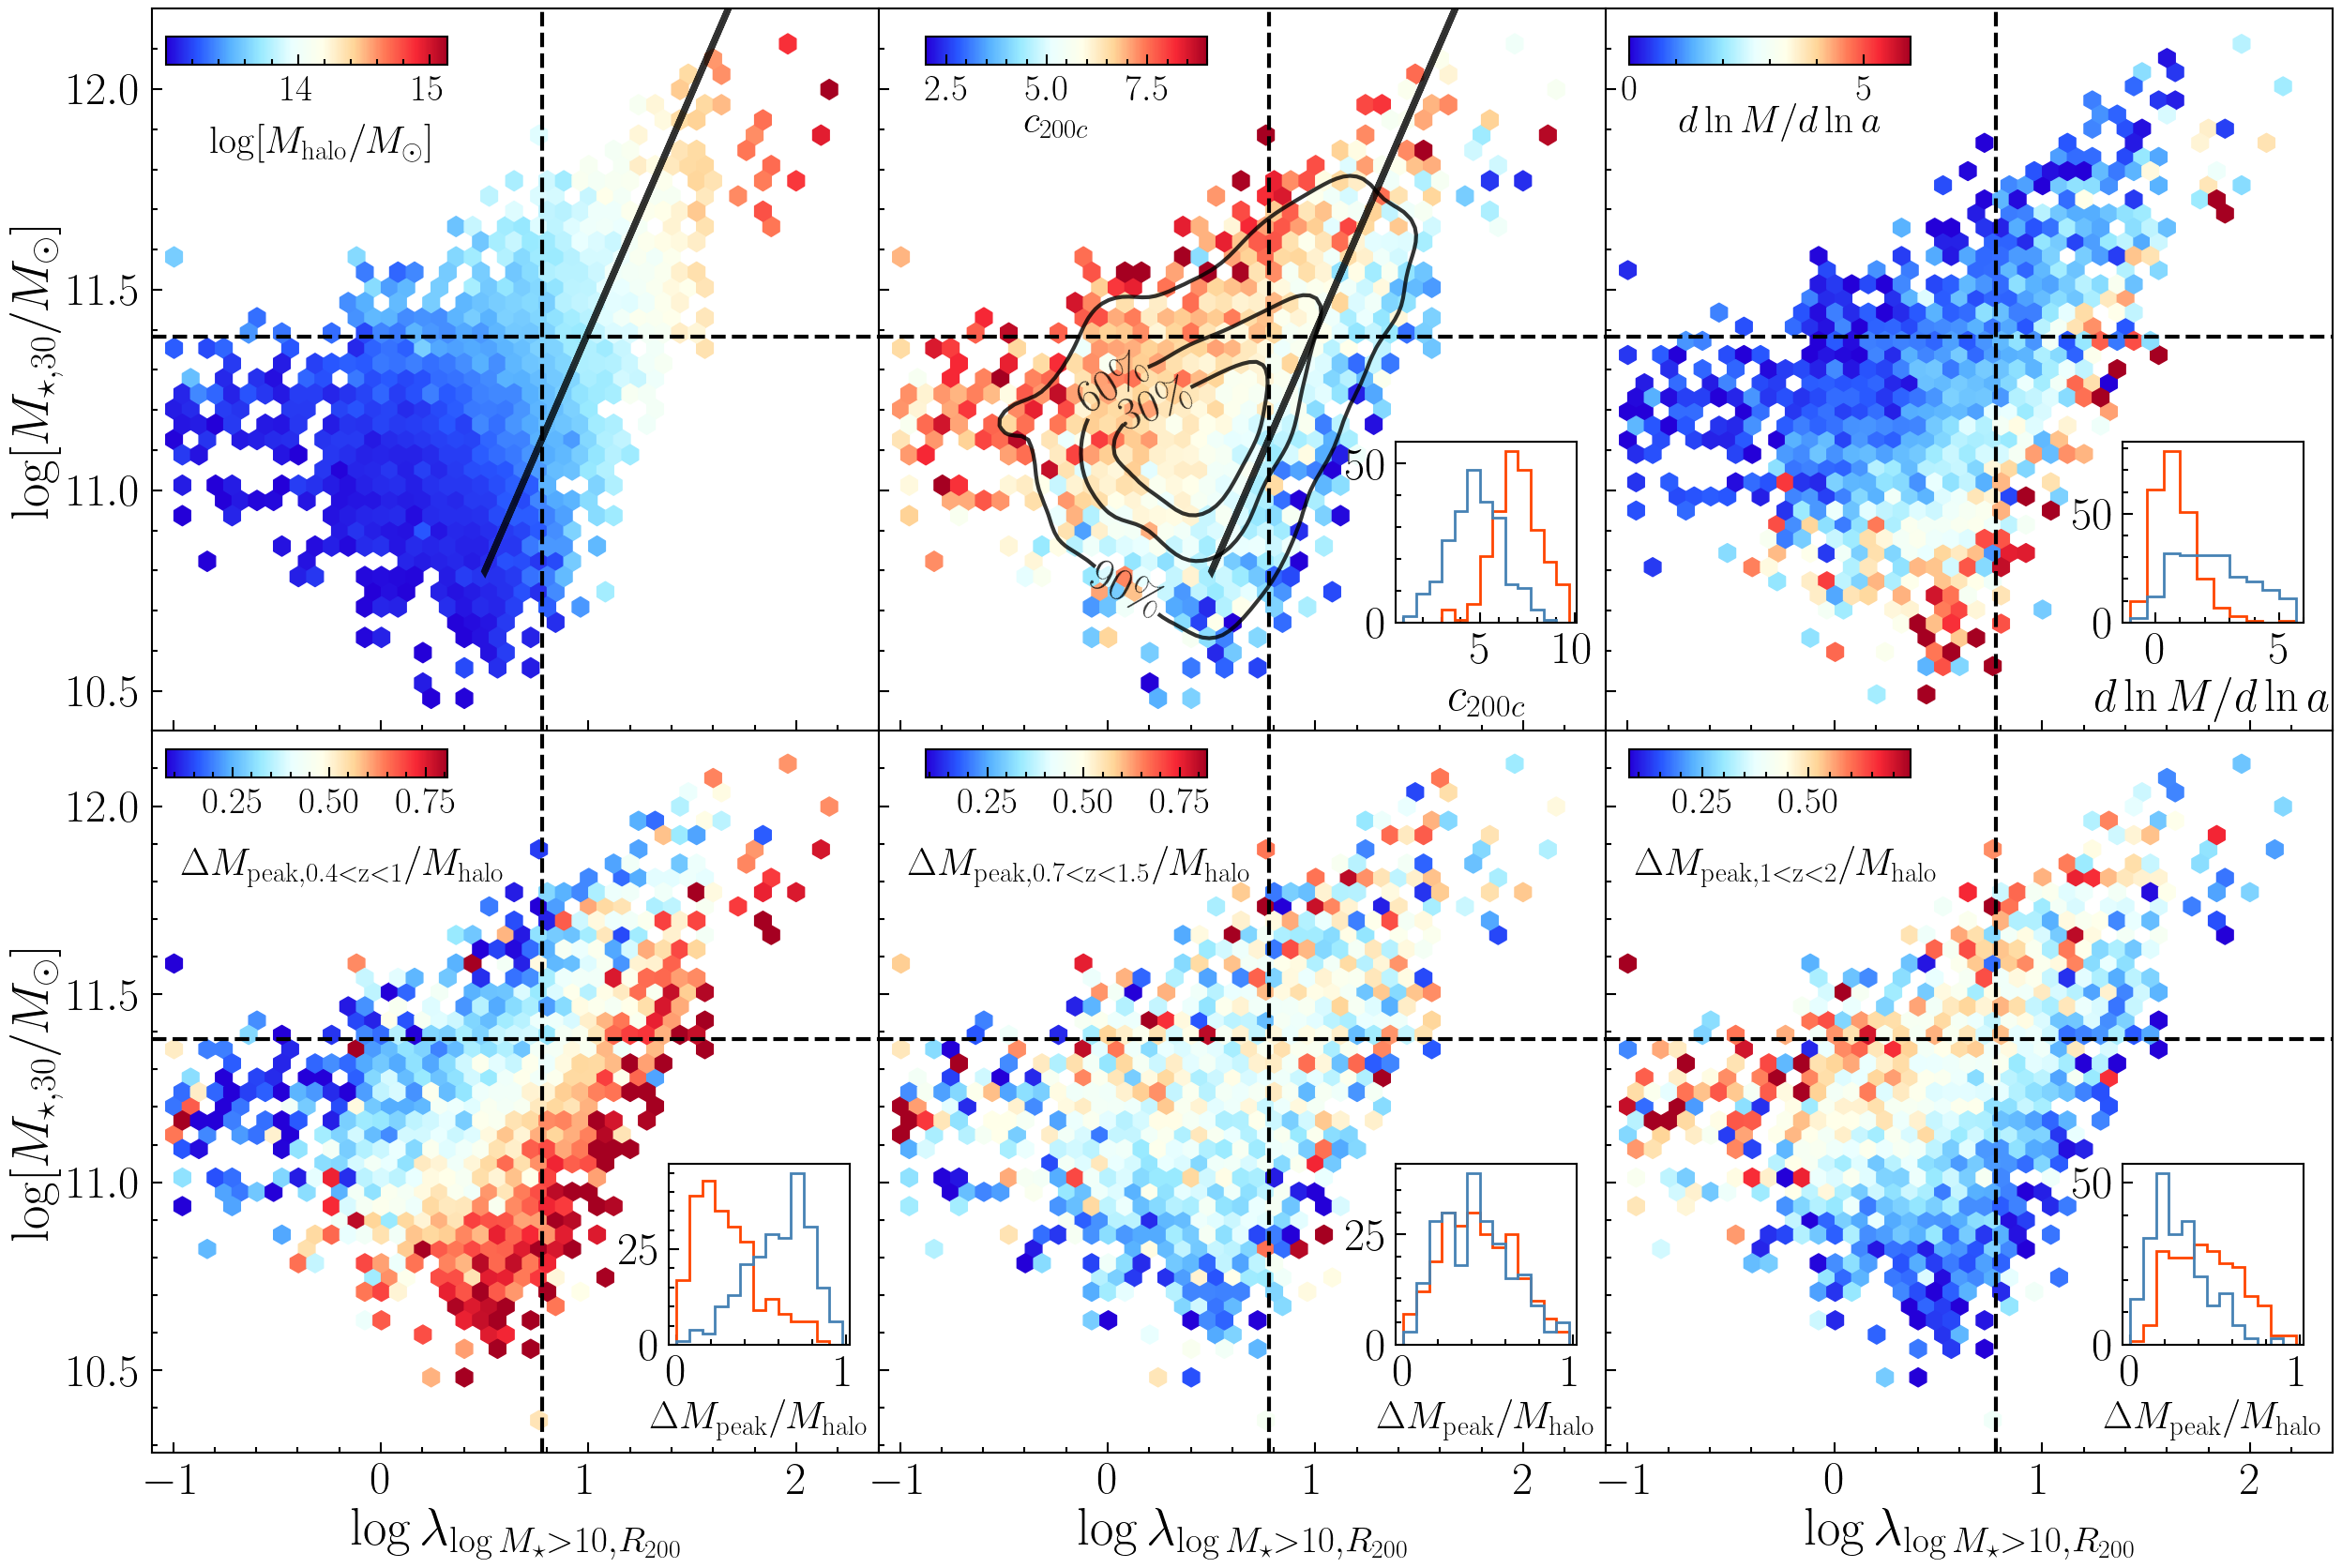

In [36]:
name='richness_cut_r200_10'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_30_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=600
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_30_gal'])
topNout=topNselect(tab2[mask1],'aper_30_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_30_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,20))
gs = fig.add_gridspec(2,3, hspace=0, wspace=0)
(ax3,ax1,ax2),(ax4,ax5,ax6)=gs.subplots(sharey='row',sharex='col')
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_30_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.83,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.1,0.83,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.8,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax4.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax4.text(0.04,0.8,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax4.transAxes,size=30)
cax = fig.add_axes([0.13, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax4.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax4.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

name_z='halo_growth_z0.7_z1.5'
mask_z=(tab2['halo_growth_z0.7_z1.5'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.7_z1.5']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax5.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax5.text(0.04,0.8,r'$\Delta M_{\rm peak,0.7<z<1.5}/M_{\rm halo}$',transform=ax5.transAxes,size=30)
cax = fig.add_axes([0.4, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax5.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax5.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

mask_z=(tab2['halo_growth_z1_z2'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z1_z2']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax6.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax6.text(0.04,0.8,r'$\Delta M_{\rm peak,1<z<2}/M_{\rm halo}$',transform=ax6.transAxes,size=30)
cax = fig.add_axes([0.65, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax6.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax6.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data['halo_growth_z1_z2']!=None)
mask_11=(down_data['halo_growth_z1_z2']!=None)
ax10.hist(up_data[mask_00]['halo_growth_z1_z2']/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11]['halo_growth_z1_z2']/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

ax4.set_xlabel(label,fontsize=40)
ax5.set_xlabel(label,fontsize=40)
ax6.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$d\ln M/d\ln a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(0,10.5),(0,11.3),(0.3,11.1)])
ax1.set_ylim(10.4,12.2)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(10.4,12.2)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(10.4,12.2)
ax3.set_xlim(-1.1,2.4)

ax4.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')
ax4.axvline(x_v,c='black',lw=3,ls='--')
ax4.axhline(y_v,c='black',lw=3,ls='--')
ax5.axvline(x_v,c='black',lw=3,ls='--')
ax5.axhline(y_v,c='black',lw=3,ls='--')
ax6.axvline(x_v,c='black',lw=3,ls='--')
ax6.axhline(y_v,c='black',lw=3,ls='--')


/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_21339/1419333979.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


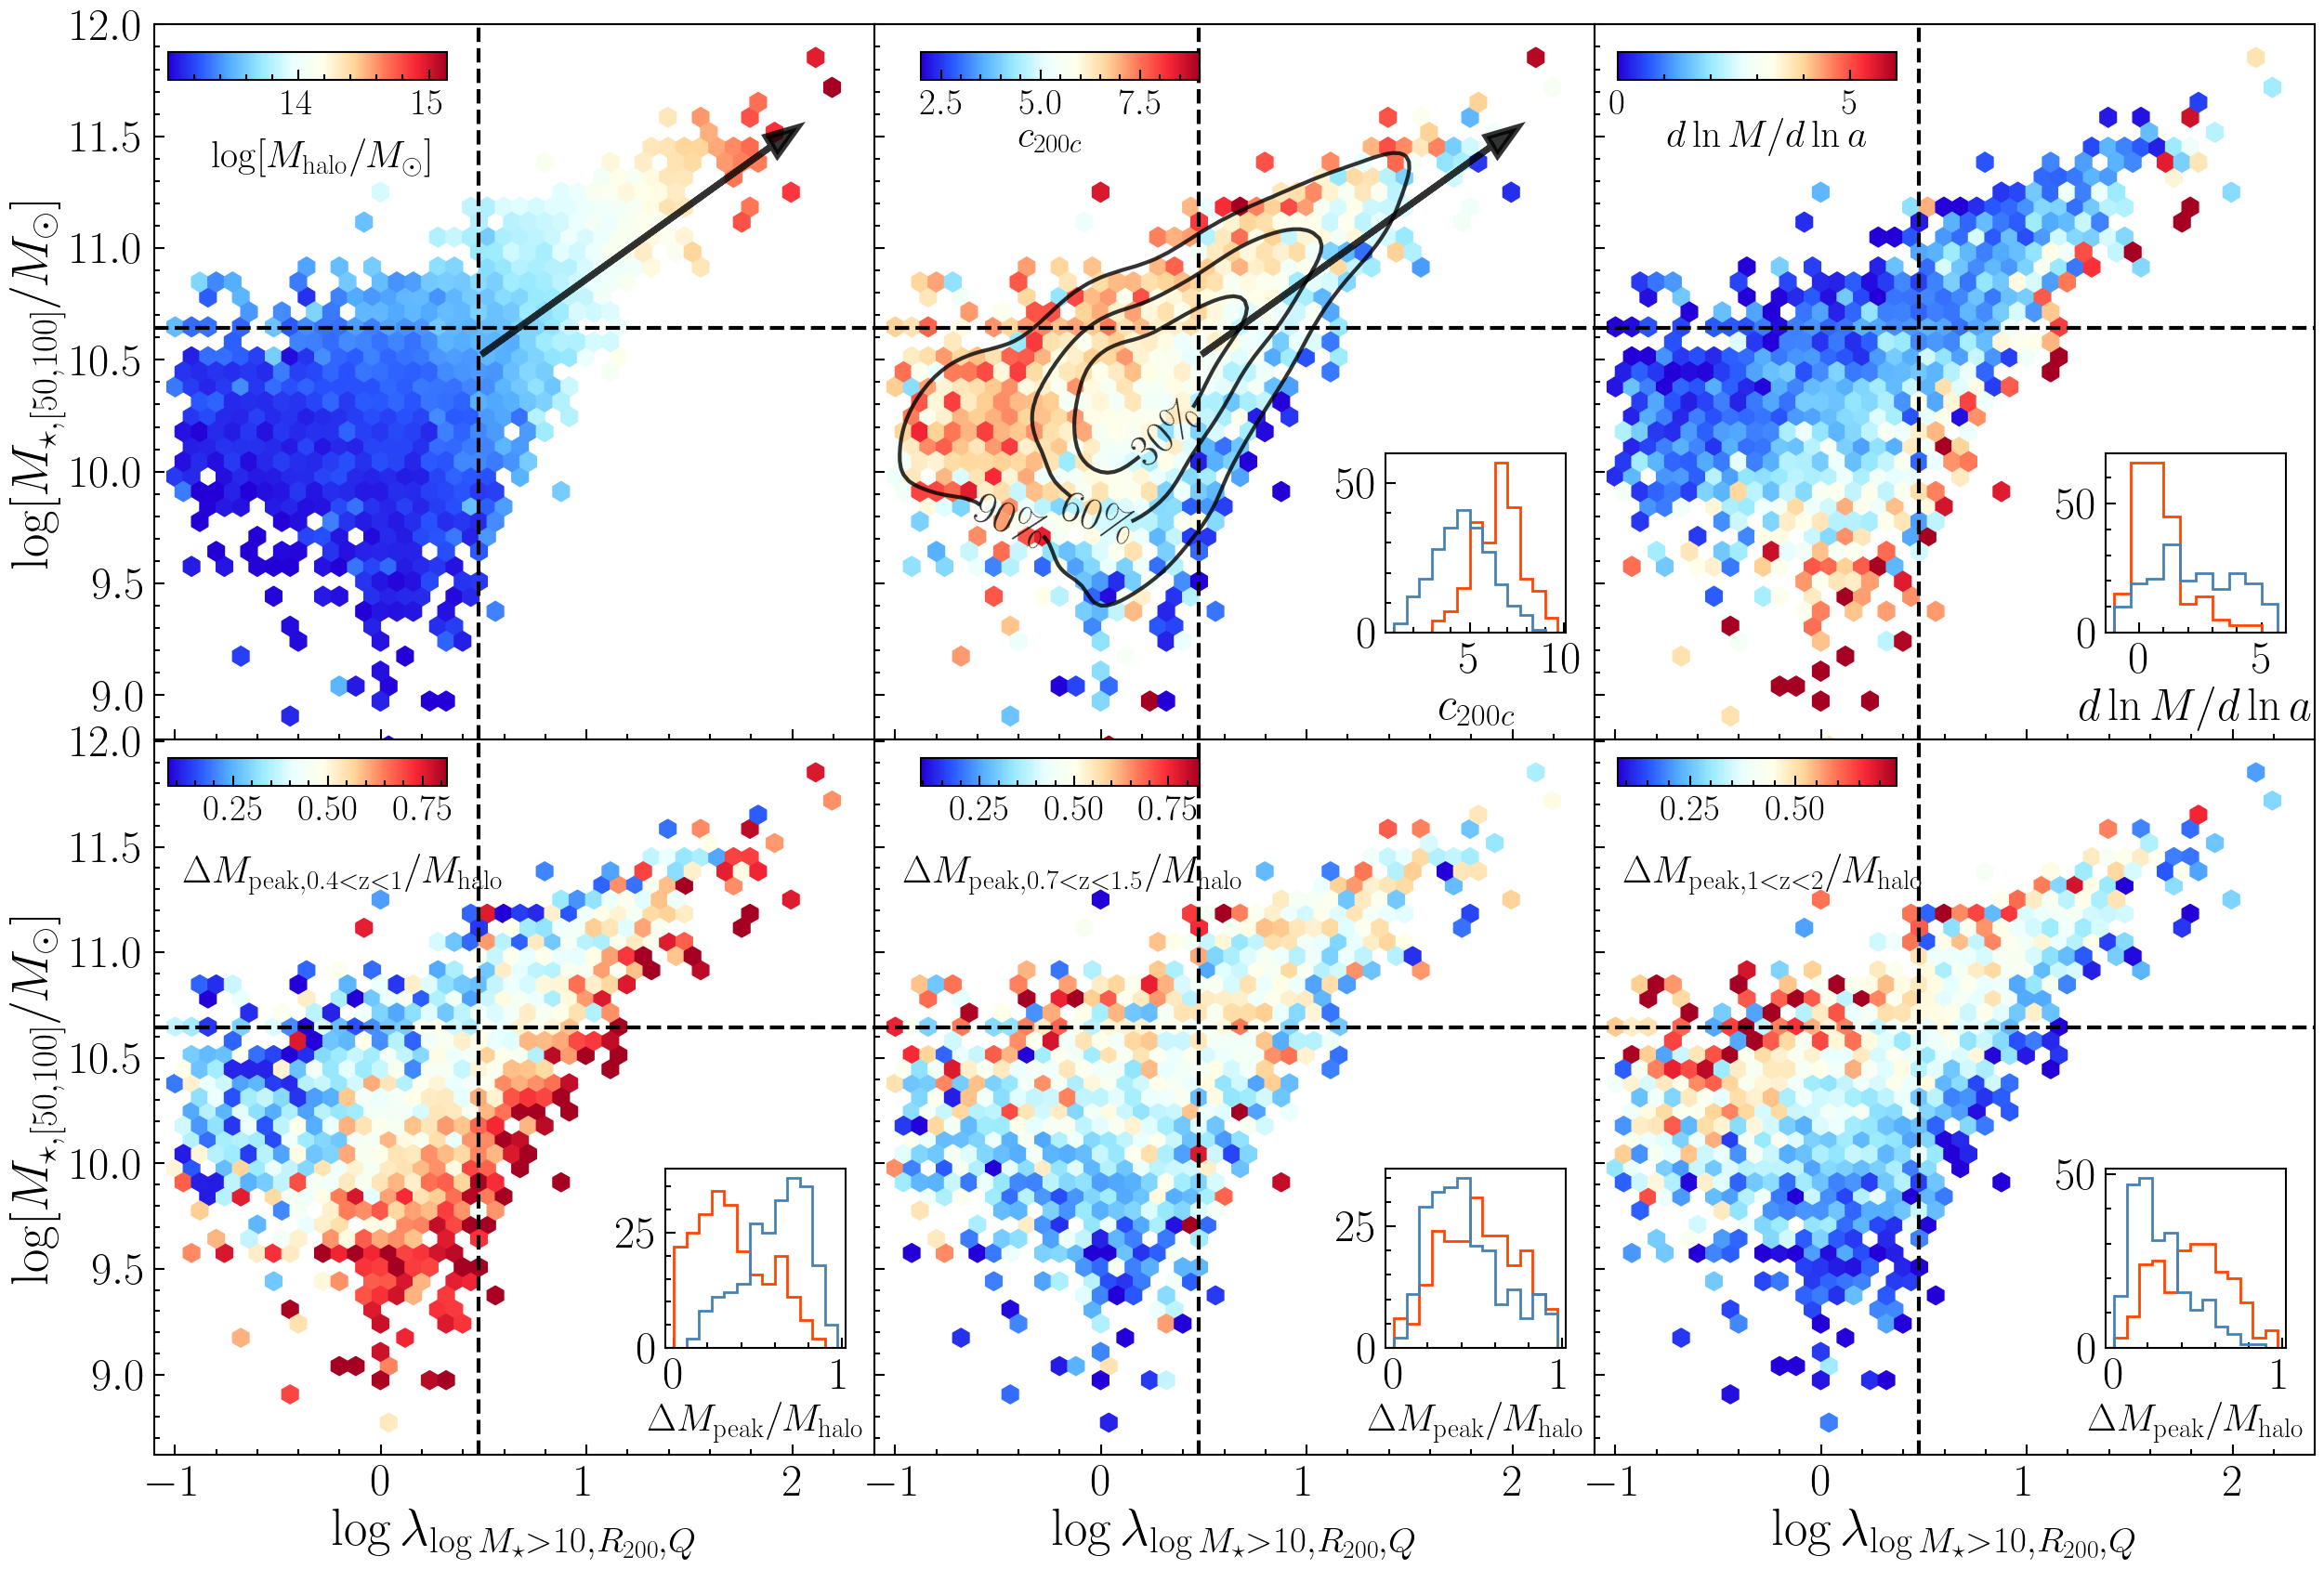

In [45]:
name='richness_cut_r200_10_Q'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,20))
gs = fig.add_gridspec(2,3, hspace=0, wspace=0)
(ax3,ax1,ax2),(ax4,ax5,ax6)=gs.subplots(sharey='row',sharex='col')
name='richness_cut_r200_10_Q'
label=r'$\log\lambda_{\log M_\star>10,R_{200},Q}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.83,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.1,0.83,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.8,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax4.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax4.text(0.04,0.8,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax4.transAxes,size=30)
cax = fig.add_axes([0.13, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax4.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax4.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

name_z='halo_growth_z0.7_z1.5'
mask_z=(tab2['halo_growth_z0.7_z1.5'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.7_z1.5']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax5.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax5.text(0.04,0.8,r'$\Delta M_{\rm peak,0.7<z<1.5}/M_{\rm halo}$',transform=ax5.transAxes,size=30)
cax = fig.add_axes([0.4, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax5.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax5.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

mask_z=(tab2['halo_growth_z1_z2'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z1_z2']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax6.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax6.text(0.04,0.8,r'$\Delta M_{\rm peak,1<z<2}/M_{\rm halo}$',transform=ax6.transAxes,size=30)
cax = fig.add_axes([0.65, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax6.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax6.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data['halo_growth_z1_z2']!=None)
mask_11=(down_data['halo_growth_z1_z2']!=None)
ax10.hist(up_data[mask_00]['halo_growth_z1_z2']/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11]['halo_growth_z1_z2']/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

ax4.set_xlabel(label,fontsize=40)
ax5.set_xlabel(label,fontsize=40)
ax6.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$d\ln M/d\ln a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(-0.5,9.5),(0,9.8),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax4.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')
ax4.axvline(x_v,c='black',lw=3,ls='--')
ax4.axhline(y_v,c='black',lw=3,ls='--')
ax5.axvline(x_v,c='black',lw=3,ls='--')
ax5.axhline(y_v,c='black',lw=3,ls='--')
ax6.axvline(x_v,c='black',lw=3,ls='--')
ax6.axhline(y_v,c='black',lw=3,ls='--')

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_21339/570388000.py:18: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


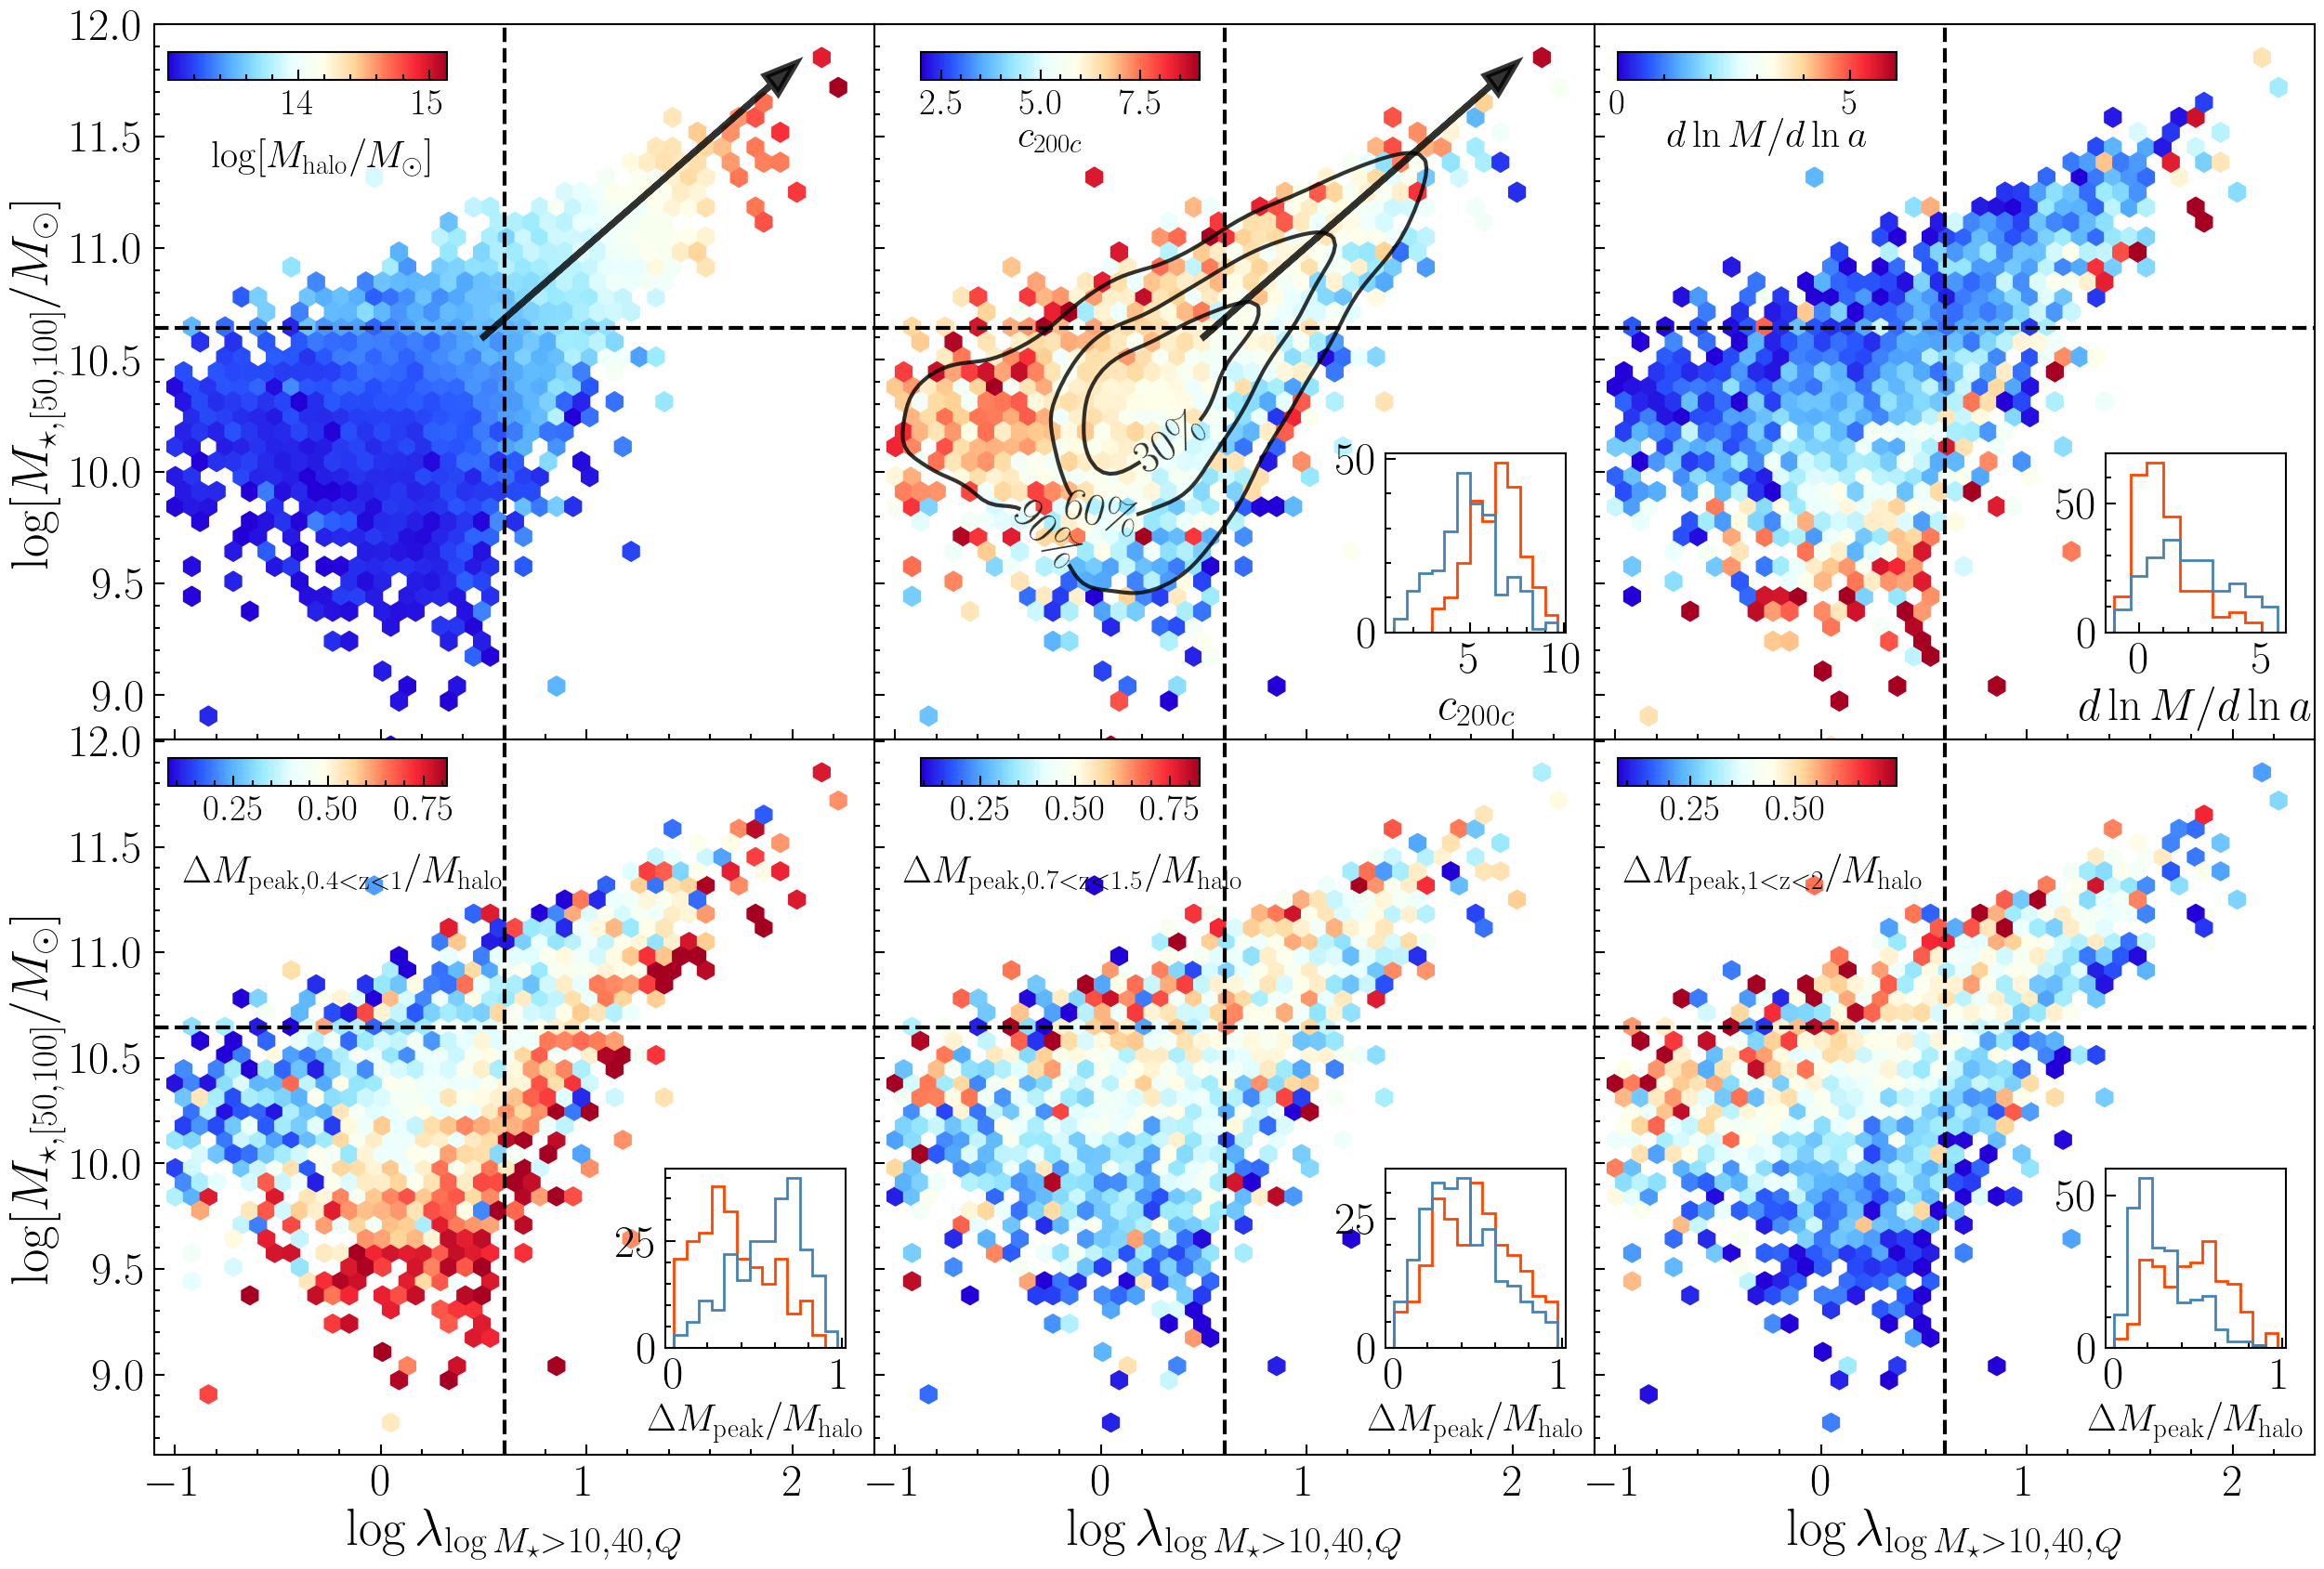

In [49]:
name='richness_cut_r200_10_xy_40_Q'
mask2=(np.log10(tab2['mass_halo'])>13.2)&(tab2[name]>0)
data=np.asarray([np.log10(tab2[mask2][name]),np.log10(tab2[mask2]['aper_100_gal']-tab2[mask2]['aper_50_gal'])]).T
zdata=np.log10(tab2[mask2]['mass_halo'])
model=LinearRegression().fit(data,zdata)
X=data
Z=zdata
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

top_numb=800
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])
                
# creating 3d plot using matplotlib 
# in python

# for creating a responsive plot
# importing required libraries
# Plotting
fig=plt.figure(figsize=(30,20))
gs = fig.add_gridspec(2,3, hspace=0, wspace=0)
(ax3,ax1,ax2),(ax4,ax5,ax6)=gs.subplots(sharey='row',sharex='col')
name='richness_cut_r200_10_xy_40_Q'
label=r'$\log\lambda_{\log M_\star>10,40,Q}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab2[mask10]['c_200c']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=2,vmax=9)

cax = fig.add_axes([0.4, 0.85, 0.1, 0.015])
ax1.text(0.2,0.83,r'$c_{200c}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=tab2[mask10]['acc_rate']
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0,vmax=6)
ax2.text(0.1,0.83,r'$d\ln M/d\ln a$',transform=ax2.transAxes,size=30)
ax10 = ax1.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax1.transAxes)
binlist=np.arange(1,10,2/3)
ax10.hist(up_data['c_200c'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['c_200c'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$c_{200c}$')
#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.65, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.8,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.85, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


name_z='halo_growth_z0.4_z1'
mask_z=(tab2['halo_growth_z0.4_z1'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.4_z1']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax4.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax4.text(0.04,0.8,r'$\Delta M_{\rm peak,0.4<z<1}/M_{\rm halo}$',transform=ax4.transAxes,size=30)
cax = fig.add_axes([0.13, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax4.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax4.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

name_z='halo_growth_z0.7_z1.5'
mask_z=(tab2['halo_growth_z0.7_z1.5'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z0.7_z1.5']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax5.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax5.text(0.04,0.8,r'$\Delta M_{\rm peak,0.7<z<1.5}/M_{\rm halo}$',transform=ax5.transAxes,size=30)
cax = fig.add_axes([0.4, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax5.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax5.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data[name_z]!=None)
mask_11=(down_data[name_z]!=None)
ax10.hist(up_data[mask_00][name_z]/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11][name_z]/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

mask_z=(tab2['halo_growth_z1_z2'][mask10]!=None)
zdata=tab2[mask10][mask_z]['halo_growth_z1_z2']/tab2[mask10][mask_z]['mass_halo']
vmin=np.percentile(zdata,5)
vmax=np.percentile(zdata,95)
SC=ax6.hexbin(xdata[mask_z],ydata[mask_z],C=zdata,cmap=cmap1,gridsize=40,vmin=vmin,vmax=vmax)
ax6.text(0.04,0.8,r'$\Delta M_{\rm peak,1<z<2}/M_{\rm halo}$',transform=ax6.transAxes,size=30)
cax = fig.add_axes([0.65, 0.47, 0.1, 0.015])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)

ax10 = ax6.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax6.transAxes)
binlist=np.arange(0,1,0.075)
mask_00=(up_data['halo_growth_z1_z2']!=None)
mask_11=(down_data['halo_growth_z1_z2']!=None)
ax10.hist(up_data[mask_00]['halo_growth_z1_z2']/up_data[mask_00]['mass_halo'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data[mask_11]['halo_growth_z1_z2']/down_data[mask_11]['mass_halo'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$\Delta M_{\rm peak}/M_{\rm halo}$',fontsize=30)

ax4.set_xlabel(label,fontsize=40)
ax5.set_xlabel(label,fontsize=40)
ax6.set_xlabel(label,fontsize=40)
ax3.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax10 = ax2.inset_axes([0.71, 0.15, 0.25,0.25], transform=ax2.transAxes)
binlist=np.arange(-1,6,2/3)
ax10.hist(up_data['acc_rate'],histtype='step',color='orangered',bins=binlist,lw=2)
ax10.hist(down_data['acc_rate'],histtype='step',color='steelblue',bins=binlist,lw=2)
ax10.set_xlabel(r'$d\ln M/d\ln a$')


xline=np.arange(0.5,2,0.1)
yline=10.2+model.coef_[1]/model.coef_[0]*xline
x0=xline[0]
y0=yline[0]
dx=xline[-1]-xline[0]
dy=yline[-1]-yline[0]
ax1.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)
ax3.arrow(x0,y0,dx,dy,color='black',alpha=0.8,lw=5,zorder=1,head_width=0.1)

x=xdata
y=ydata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid over which we will evaluate the KDE
xmin, xmax = x.min() , x.max() 
ymin, ymax = y.min() , y.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kernel(positions).T, xx.shape)
sorted_zi=np.sort(kernel(positions).T)
cumulative_zi=np.cumsum(sorted_zi)/np.sum(sorted_zi)
t_30=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.7))]
t_60=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.4))]
t_90=sorted_zi[np.argmin(np.abs(cumulative_zi - 0.1))]
CS=ax1.contour(xx,yy,f,levels=[t_90,t_60,t_30],colors=['black','black','black'],linewidths=3,alpha=0.8)
fmt={}
str0=[r'$90\%$',r'$60\%$',r'$30\%$']
for l, s in zip(CS.levels, str0):
    fmt[l] = s
ax1.clabel(CS,inline=True,fmt=fmt,inline_spacing=1,manual=[(-0.5,9.5),(0,9.8),(0.3,10.2)])
ax1.set_ylim(8.8,12)
ax1.set_xlim(-1.1,2.4)
ax2.set_ylim(8.8,12)
ax2.set_xlim(-1.1,2.4)
ax3.set_ylim(8.8,12)
ax3.set_xlim(-1.1,2.4)

ax4.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')
ax3.axvline(x_v,c='black',lw=3,ls='--')
ax3.axhline(y_v,c='black',lw=3,ls='--')
ax4.axvline(x_v,c='black',lw=3,ls='--')
ax4.axhline(y_v,c='black',lw=3,ls='--')
ax5.axvline(x_v,c='black',lw=3,ls='--')
ax5.axhline(y_v,c='black',lw=3,ls='--')
ax6.axvline(x_v,c='black',lw=3,ls='--')
ax6.axhline(y_v,c='black',lw=3,ls='--')